In [ ]:
from hiprof import IDAlgorithm, HPFalsifier

Consider the following graphs.

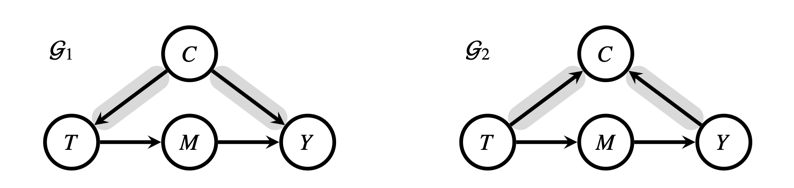

In [ ]:
g1 = "T -> M; M -> Y; C -> T; C -> Y"
g2 = "T -> M; M -> Y; T -> C; Y -> C"

We first find an identifying formula for each graph with the ID algorithm.

In [ ]:
id1 = IDAlgorithm(
    graph=g1,
    treatments="T",
    outcomes="Y",
)
phi1 = id1.run()
phi1

The above formula can be simplified as

In [ ]:
phi1 = "sum_{C}{ p(Y | C, T) p(C) }"

In [ ]:
id2 = IDAlgorithm(
    graph=g2,
    treatments="T",
    outcomes="Y",
)
phi2 = id2.run()
phi2

The above formula can be simplified as

In [ ]:
phi2 = "p(Y | T)"

Each formula is specific to its graph and fails for the other:

In [ ]:
falsifier1 = HPFalsifier(
    graph=g1,
    treatments="T",
    outcomes="Y",
)
falsifier1.check(phi2)

In [ ]:
falsifier2 = HPFalsifier(
    graph=g2,
    treatments="T",
    outcomes="Y",
)
falsifier2.check(phi1)

A different formula can be identifying for both:

In [ ]:
phi3 = "sum_{M}{ p(M | T) sum_{T'} { p(Y | M, T') p(T') } }"

In [ ]:
falsifier1.check(phi3)

In [ ]:
falsifier2.check(phi3)